### 2 Conversion Rate +

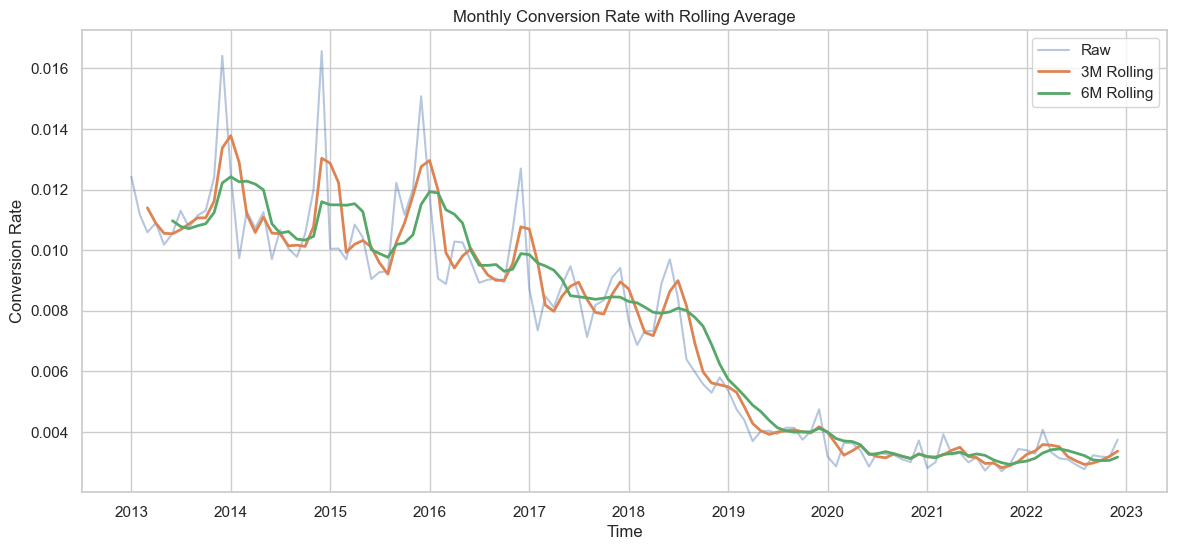

In [2]:
# Monthly conversion + rolling 3M & 6M
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# Load data
orders = pd.read_csv("data/orders.csv", parse_dates=["order_date"])
traffic = pd.read_csv("data/web_traffic.csv", parse_dates=["date"])

# Align thời gian
start_date = traffic["date"].min()
orders = orders[orders["order_date"] >= start_date].copy()

# Tạo month
orders["month"] = orders["order_date"].dt.to_period("M")
traffic["month"] = traffic["date"].dt.to_period("M")

# Aggregate
monthly_orders = orders.groupby("month").size().rename("orders")
monthly_sessions = traffic.groupby("month")["sessions"].sum().rename("sessions")

df = pd.concat([monthly_orders, monthly_sessions], axis=1).fillna(0)

# Conversion rate
df["conversion_rate"] = df["orders"] / df["sessions"]

# Rolling
df["cr_3m"] = df["conversion_rate"].rolling(3).mean()
df["cr_6m"] = df["conversion_rate"].rolling(6).mean()

# Convert index sang datetime để plot đẹp
df.index = df.index.to_timestamp()

# Visualization
plt.figure(figsize=(14, 6))

# Raw
plt.plot(df.index, df["conversion_rate"], label="Raw", alpha=0.4)

# Rolling
plt.plot(df.index, df["cr_3m"], label="3M Rolling", linewidth=2)
plt.plot(df.index, df["cr_6m"], label="6M Rolling", linewidth=2)

plt.title("Monthly Conversion Rate with Rolling Average")
plt.xlabel("Time")
plt.ylabel("Conversion Rate")

plt.legend()
plt.show()

Conversion rate = (tổng order 1 tháng) / (session 1 tháng)
- orders.csv và web_traffic.csv không có chung 1 mốc bắt đầu nên ta sẽ phải cắt đi tất cả các order trước 2013-1-1 ( điểm bắt đầu của web_traffic ) để tính conversion_rate 
- sau khi quan sát ta chia ra thành 2 mốc 
    - Trước 2019: 
    raw: biến động lên xuống mạnh mẽ, nhưng khá có tính chu kì, tăng mạnh ở những tháng cuối năm nhưng giảm liên tục đến đầu năm sau đó rồi lại bình ổn đến cuối năm 
    3m và 6m: tương tự có tính biến động chu kì như vậy nhưng đến 2017 có xu hướng đi xuống rõ rệt
    - Sau 2019: cả 3 đường đều giảm theo U-shape
> Như vậy chuyện sụp đổ ở 2019 có lẽ không phải là đột ngột, đó chỉ là hệ quả âm thầm từ 2017-2018

- hơn hết ta thấy conversion rate rất thấp, max 1.6% min 0.4%

### 4 Ngưỡng chịu đựng của khách hàng

4.1 Ngưỡng chịu đựng đối với late delivery